[Super Tiny Language Models](https://arxiv.org/pdf/2405.14159)

[Hugging Face Transformers](https://huggingface.co/docs/transformers/en/index)

[Hugging Face Llama](https://huggingface.co/docs/transformers/en/model_doc/llama#llama)

[BabyLM](https://babylm.github.io/papers.html)

[](https://arxiv.org/pdf/2405.14159)

In [2]:
train_nl_file_path = "dataset/train.nl.filtered"
train_bash_file_path = "dataset/train.cm.filtered"
# CORPUS_FILE_PATH = "dataset/corpus.txt"

from datasets import load_dataset, Dataset, interleave_datasets, concatenate_datasets

In [3]:
TOKEN_START = "<s>"
TOKEN_STOP = "</s>"
TOKEN_PAD = "<pad>"
TOKEN_SPLIT = "<sep>"
TOKEN_UNK = "<unk>"
VOCAB_SIZE = 8192
MAX_LEN = 256

In [4]:
import sys
import os
module_path = os.path.abspath(os.path.join('clai/submission-code/src/'))
# print(module_path)
sys.path.insert(0, module_path)
# import bashlint.bash as bash
# from bashlint.data_tools import *

In [5]:
from clai.utils.bashlint.data_tools import ast2template, bash_parser


Setting bashlex grammar using file: c:\Users\Steam\Documents\ece285_proj\clai\submission-code\src\bashlint\grammar\grammar100.txt
Bashlint grammar set up (148 utilities)



In [6]:
with open("dataset/test.nl.filtered", "r") as f:
    nl_lines = f.read().splitlines()
        
with open("dataset/test.cm.filtered", "r") as f:
    bash_lines = f.read().splitlines()

test_dataset = {"nl" : [],
                 "bash" : []}
                 
for nl, bash in zip(nl_lines, bash_lines):
    try:
        test_dataset["bash"].append(ast2template(bash_parser(bash)))
        test_dataset["nl"].append(nl)
    except Exception as e:
        #print(f"Error processing bash line: {bash}")
        #print(f"Error: {e}")
        pass

print(len(test_dataset["bash"]), len(bash_lines))
print(test_dataset["bash"][:5])
test_dataset = Dataset.from_dict(test_dataset)

609 779
['rename Regex Regex', 'rename Regex Regex', 'nl -s Regex File | cut -c Number', 'echo Regex | nl -b a -s Regex', 'history -r Quantity']


  command   val
0    find  5520
1    echo   189
2     cat   128
3   mkdir   125
4   chown   109
5      ls   104
6   rsync    88
7    grep    70
8    read    69
9      ln    62
  command   val
0    find  5582
1   which  1115
2     cat  1077
3  finger   966
4      ls   954
5      mv   945
6      ln   944
7   shopt   943
8    grep   941
9   sleep   927
Original Distribution:
root_cmd
find        5582
which       1115
cat         1077
finger       966
ls           954
mv           945
ln           944
shopt        943
grep         941
sleep        927
apropos      918
history      917
chgrp        916
cd           906
mkdir        890
w            880
jobs         877
dirname      868
yes          846
ifconfig     845
Name: count, dtype: int64
Length of augmented training set: 57636
Length of original training set: 8159
Length of part augment training set: 33734


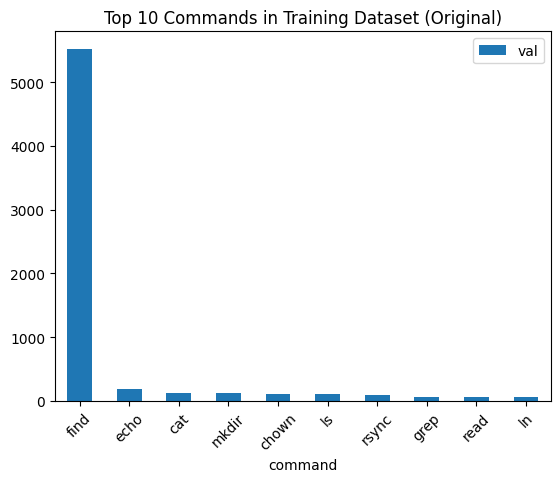

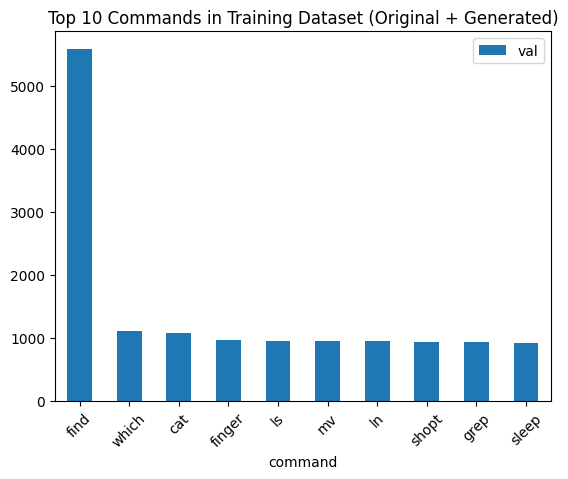

In [7]:
import pandas as pd
from datasets import Dataset

with open("dataset_postprocessed/train.nl.filtered", "r") as f:
    nl_lines = f.read().splitlines()
        
with open("dataset_postprocessed/train.cm.filtered", "r") as f:
    bash_lines = f.read().splitlines()


with open("dataset_postprocessed/generated_400.nl", "r") as f:
    nl_lines_generated = [i.removesuffix(".") for i in f.read().splitlines()]
        
with open("dataset_postprocessed/generated_400.cm", "r") as f:
    bash_lines_generated = f.read().splitlines()

    
with open("dataset_postprocessed/generated_400_1.nl", "r") as f:
    nl_lines_generated_1 = [i.removesuffix(".") for i in f.read().splitlines()]
        
with open("dataset_postprocessed/generated_400_1.cm", "r") as f:
    bash_lines_generated_1 = f.read().splitlines()


train_dataset = Dataset.from_dict({
    "nl": nl_lines + nl_lines_generated + nl_lines_generated_1,
    "bash": bash_lines + bash_lines_generated + bash_lines_generated_1
})

with open("dataset_postprocessed/joined.cm", "w") as f:
    f.write("\n".join(train_dataset["bash"]))
with open("dataset_postprocessed/joined.nl", "w") as f:
    f.write("\n".join(train_dataset["nl"]))

df = pd.DataFrame(train_dataset)

df["root_cmd"] = df["bash"].apply(lambda x: x.split()[0] if isinstance(x, str) and len(x.split()) > 0 else "unknown")

df1 = pd.DataFrame({"bash": bash_lines, "nl": nl_lines})
df1["root_cmd"] = df1["bash"].apply(lambda x: x.split()[0] if isinstance(x, str) and len(x.split()) > 0 else "unknown")
d = df1["root_cmd"].value_counts().reset_index().head(10)
d.columns = ["command", "val"]
ax = d.plot.bar(x="command", y="val", rot=45, title="Top 10 Commands in Training Dataset (Original)")
print(d)
len(df1)

# df = ({"lab": ["A", "B", "C"], "val": [10, 30, 20]})
d = df["root_cmd"].value_counts().reset_index().head(10)
d.columns = ["command", "val"]
ax = d.plot.bar(x="command", y="val", rot=45, title="Top 10 Commands in Training Dataset (Original + Generated)")
print(d)

print("Original Distribution:")
print(df["root_cmd"].value_counts().head(20))

print(f"Length of augmented training set: {len(df)}")
print(f"Length of original training set: {len(df1)}")
print(f"Length of part augment training set: {len(bash_lines) + len(nl_lines_generated)}")
# print(df["root_cmd"].nunique())

In [8]:
all_words = set()
for bash in train_dataset["bash"]:
    all_words.update(bash.split())
print(f"Unique words in bash commands: {len(all_words)}")
for nl in train_dataset["nl"]:
    all_words.update(nl.split())
print(f"Unique words total: {len(all_words)}")

Unique words in bash commands: 2184
Unique words total: 21377


In [ ]:
from tokenizers import Tokenizer
from tokenizers.models import BPE
from tokenizers.pre_tokenizers import ByteLevel
from tokenizers.trainers import BpeTrainer
from transformers import PreTrainedTokenizerFast
import numpy as np
import matplotlib.pyplot as plt
from transformers import DataCollatorForLanguageModeling, Trainer, TrainingArguments
from tokenizers import decoders


# Llama and gpt-2 both use byte-level BPE so..
# let's try to emulate the Llama tokenizer, with our own vocab limit and additional special token
tokenizer = Tokenizer(BPE(unk_token = TOKEN_UNK))
tokenizer.pre_tokenizer = ByteLevel(add_prefix_space = False)

special_tokens = [TOKEN_STOP, TOKEN_SPLIT, TOKEN_START, TOKEN_UNK, TOKEN_PAD]

# https://huggingface.co/docs/transformers/en/tokenizer_summary
trainer = BpeTrainer(
    vocab_size = VOCAB_SIZE, 
    special_tokens = special_tokens,
    show_progress = True,
    initial_alphabet = ByteLevel.alphabet()
)

#from datasets import Dataset
#raw_dataset = Dataset.from_dict(data)
files = ["dataset_postprocessed/joined.nl", "dataset_postprocessed/joined.cm"]

tokenizer.train(files = files, trainer = trainer)

# wrap for huggingface 
fast_tokenizer = PreTrainedTokenizerFast(
    tokenizer_object = tokenizer,
    unk_token = TOKEN_UNK,
    bos_token = TOKEN_START,
    eos_token = TOKEN_STOP,
    pad_token = TOKEN_PAD # i think by default pad_token is set to eos
)

# print(f"final vocabulary size: {fast_tokenizer.vocab_size}")
fast_tokenizer._tokenizer.decoder = decoders.ByteLevel()

fast_tokenizer.save_pretrained("./nl2bash_tokenizer")
print(f"final vocabulary size: {fast_tokenizer.vocab_size}")

final vocabulary size: 8192


Mean Length: 30.978796421130042 tokens
Median Length: 29.0 tokens
Max length: 239 tokens
90th pct: 46.0 tokens
99th pct: 68.0 tokens
99.9th pct: 96.0 tokens


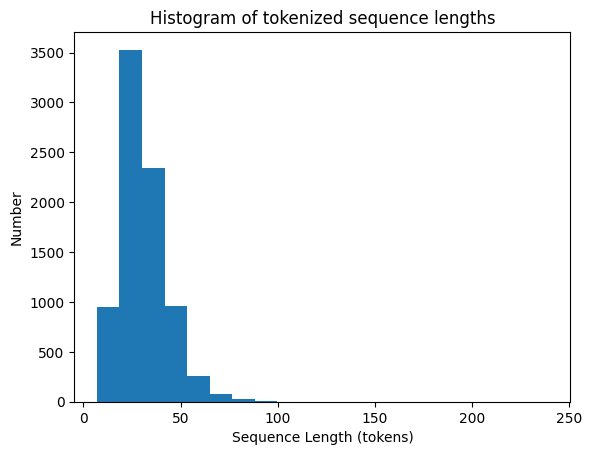

In [10]:
sequence_lengths = []

for nl, bash in zip(nl_lines, bash_lines):
    sequence = f"{TOKEN_START}{nl}{TOKEN_SPLIT}{bash}{TOKEN_STOP}"    
    token_ids = tokenizer.encode(sequence)
    sequence_lengths.append(len(token_ids))

lengths = np.array(sequence_lengths)
    
mean_len = np.mean(lengths)
median_len = np.median(lengths)
max_len = np.max(lengths)
p90_len = np.percentile(lengths, 90)

print(f"Mean Length: {mean_len} tokens")
print(f"Median Length: {median_len} tokens")
print(f"Max length: {max_len} tokens")
print(f"90th pct: {np.percentile(lengths, 90)} tokens")
print(f"99th pct: {np.percentile(lengths, 99)} tokens")
print(f"99.9th pct: {np.percentile(lengths, 99.9)} tokens")

plt.hist(lengths, bins=20)
plt.title("Histogram of tokenized sequence lengths")
plt.xlabel("Sequence Length (tokens)")
plt.ylabel("Number")
plt.show()

In [11]:
# https://huggingface.co/docs/datasets/en/quickstart
def tokenize_function(examples):
    formatted_texts = [f"{TOKEN_START}{nl}{TOKEN_SPLIT}{bash}{TOKEN_STOP}"
        for nl, bash in zip(examples["nl"], examples["bash"])]
    
    # Tokenize the sequences
    tokenized = fast_tokenizer(
        formatted_texts,
        truncation = True,
        max_length = MAX_LEN,         
        padding = "max_length"
    )

    # tokenized["labels"] = tokenized["input_ids"].copy()
    
    return tokenized

In [12]:
from transformers import LlamaConfig, LlamaForCausalLM

'''
The Llama model is based on the GPT architecture
- but it uses pre-normalization to improve training stability, 
- replaces ReLU with SwiGLU to improve performance, and 
- replaces absolute positional embeddings with rotary positional embeddings (RoPE)
Source: Hugging face Llama documentation
'''

config  =  LlamaConfig(
    vocab_size = VOCAB_SIZE,            
    hidden_size = 256,             
    intermediate_size = 768,      
    num_hidden_layers = 4,         
    num_attention_heads = 8,      
    num_key_value_heads = 2,       # group size = 4 (16 Q heads / 4 group size = 4 KV heads)
    max_position_embeddings = MAX_LEN, # reasonable seq length based on our data analysis
    attention_dropout = 0.1,       
    tie_word_embeddings = True,    # Tying embedding and LM head weights
    use_cache = True               
)

model = LlamaForCausalLM(config)
model = model.to('cuda') 

total_params = sum(p.numel() for p in model.parameters())
print(f"total parameters: {total_params}")

total parameters: 5114112


In [13]:
train_dataset = train_dataset.map(tokenize_function, batched = True)
test_dataset = test_dataset.map(tokenize_function, batched = True)


Map:   0%|          | 0/57636 [00:00<?, ? examples/s]

Map:   0%|          | 0/609 [00:00<?, ? examples/s]

In [ ]:
eval_steps = 100

data_collator_pretrain = DataCollatorForLanguageModeling(tokenizer = fast_tokenizer, mlm = False)

pretrain_args = TrainingArguments(
    output_dir = "./model_pretrain",
    num_train_epochs = 5, 
    per_device_train_batch_size = 32,
    learning_rate = 1e-4, 
    lr_scheduler_type = "cosine",
    warmup_ratio = 0.1,
    weight_decay = 0.1, 
    fp16 = True,
    eval_strategy = "steps",
    save_steps = eval_steps,
    eval_steps = eval_steps,
    logging_steps = eval_steps
)

pretrain_trainer = Trainer(
    model = model,
    args = pretrain_args,
    train_dataset = train_dataset,
    eval_dataset = test_dataset,
    data_collator = data_collator_pretrain,
)

# run stage 1 (pretrain)
pretrain_trainer.train() 

In [ ]:
history = pretrain_trainer.state.log_history

train_loss = [log['loss'] for log in history if 'loss' in log]
train_steps = [log['step'] for log in history if 'loss' in log]

eval_loss = [log['eval_loss'] for log in history if 'eval_loss' in log]
eval_steps = [log['step'] for log in history if 'eval_loss' in log]

plt.figure(figsize=(10, 6))
plt.plot(train_steps, train_loss, label='Training Loss', color='blue')

# Only plot eval loss if you actually ran evaluation during training
if eval_loss:
    plt.plot(eval_steps, eval_loss, label='Validation Loss', color='orange')

plt.xlabel('Training Steps')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
from clai.utils.metric import metric_utils
import numpy as np
import torch
import importlib
importlib.reload(metric_utils)

def score_dataset(model, test_dataset, fast_tokenizer, max_eval_examples = None):
    predicted_confidence = 1.0

    n_examples = len(test_dataset) if max_eval_examples is None else min(max_eval_examples, len(test_dataset))

    metric_scores = []
    parse_failures = 0

    model.eval()
    for idx in range(n_examples):
        nl_query = test_dataset[idx]["nl"]
        ground_truth = test_dataset[idx]["bash"]

        prompt = f"{TOKEN_START}{nl_query}{TOKEN_SPLIT}"
        inputs = fast_tokenizer(prompt, return_tensors="pt").to(model.device)

        with torch.no_grad():
            output_ids = model.generate(
                **inputs,
                max_new_tokens=128,
                pad_token_id=fast_tokenizer.pad_token_id,
                eos_token_id=fast_tokenizer.eos_token_id,
                num_beams=3,
                early_stopping=True,
                #do_sample = True,
                #temperature = 0.7,
                #top_p = 0.9
            )[0]

        decoded = fast_tokenizer.decode(output_ids, skip_special_tokens=False)
        if TOKEN_SPLIT in decoded:
            predicted_cmd = decoded.split(TOKEN_SPLIT, 1)[1]
        else:
            predicted_cmd = decoded.replace(prompt, "", 1)
        
        predicted_cmd = predicted_cmd.replace('\xa0', ' ').replace('–', '-')
        predicted_cmd = predicted_cmd.split(TOKEN_STOP, 1)[0].strip()
        try:
            metric_val = metric_utils.compute_metric(predicted_cmd, predicted_confidence, ground_truth)
            metric_scores.append(float(metric_val))
        except Exception:
            parse_failures += 1
            metric_scores.append(0.0)

    mean_metric = float(np.mean(metric_scores)) if metric_scores else 0.0
    print(f"Validation samples: {n_examples}")
    print(f"Mean metric score: {mean_metric:.4f}")
    print(f"Parse failures (scored as 0): {parse_failures}")

In [ ]:
def dump_ast(node, indent=0):
    # Print the current node's type and value
    node_type = type(node).__name__
    node_val = getattr(node, 'value', 'N/A')
    is_util = getattr(node, 'is_utility', lambda: False)()
    is_opt = getattr(node, 'is_option', lambda: False)()

    print("  " * indent + f"[{node_type}] value: {node_val} Utility: {is_util} Option: {is_opt}")
    
    # Recurse through children if they exist
    if hasattr(node, 'children'):
        for child in node.children:
            dump_ast(child, indent + 1)

In [ ]:
model = model.from_pretrained("./model_pretrain/checkpoint-12600").to('cuda')

In [ ]:
with open("dataset/dev.nl.filtered", "r") as f:
    val_nl_lines = f.read().splitlines()
with open("dataset/dev.cm.filtered", "r") as f:
    val_bash_lines = f.read().splitlines()
val_dict = {"nl" : val_nl_lines,
            "bash" : val_bash_lines}
val_dataset = Dataset.from_dict(val_dict)
score_dataset(model, val_dataset, fast_tokenizer)